# **Machine Learning - Assignment - Classical Pipeline**
### *Dataset: [Cat vs. Dog](https://www.kaggle.com/datasets/tongpython/cat-and-dog/versions/1)*

**Course:** Machine Learning | **Supervisor:** TS. Truong Vinh Lan | **Group 7**

| # | Member | Student ID |
|---|--------|------------|
| 1 | Nguyen Manh Quoc Khanh | 2352525 |
| 2 | Phan Ngoc Lan Chi | 2352137 |
| 3 | Ngo Diem Quyen | 2353031 |
| 4 | Tran Lam Anh | 2352067 |
| 5 | Vu Duc Viet Anh | 2352074 |

---

## Overview

This notebook implements the **Classical Machine Learning Pipeline** for binary image classification (Cat vs. Dog).
Shared modules from `modules/` are used throughout for consistency and reusability.

```
0. Configuration
      |
1. EDA
   1.1 Data setup (download, registry, audit metrics)
   1.2 Label & spatial distribution
   1.3 Image quality metrics
   1.4 Colour & missing value audit
      |
2. Preprocessing
   2.1 Data cleaning (blur, size, monochrome, duplicates)
   2.2 Spatial outlier removal
   2.3 Stratified train / val / test split
   2.4 Transform preview
      |
3. Feature Extraction  (pretrained CNN -> .npy cache)
      |
4. Classifier Training  (LR / SVM / RF / Ensemble)
      |
5. Evaluation  (metrics, confusion matrix, error gallery)
      |
6. Conclusion
```


---
## 0. Configuration

Edit **only** `USER_CONFIG` to change any experimental setting.
All downstream sections read from the merged `CONFIG` dict.



### 0.1 Environment setup

In [ ]:
import os, sys, subprocess
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    REPO_URL = "https://github.com/kahn-29/252-MachineLearning-Assignment1.git"
    REPO_DIR = Path("/content/Submission")
    if not (REPO_DIR / "modules").exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    os.chdir(REPO_DIR)
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    print("Colab project root:", Path.cwd())
else:
    print("Local environment. Current root:", Path.cwd())

from modules.config_utils import resolve_workspace, ensure_dirs

WORKSPACE = resolve_workspace(project_name="classical_pipeline")
FEATURE_DIR = WORKSPACE / "features"
FIGURE_DIR  = WORKSPACE / "figures"
MODEL_DIR   = WORKSPACE / "models"
ensure_dirs(FEATURE_DIR, FIGURE_DIR, MODEL_DIR)
print("Workspace:", WORKSPACE)

: 

### 0.2 Parameter reference

| Group | Key | Default | Description |
|-------|-----|---------|-------------|
| `DATASET` | `kaggle_id` | `tongpython/cat-and-dog` | Kaggle dataset identifier |
| `CLEANING` | `blur_laplacian_min` | `40` | Min Laplacian variance; lower -> blurry |
| | `min_side_min` | `64` | Min side length in px |
| | `near_mono_ratio_max` | `0.92` | Max near-black+near-white pixel fraction |
| | `aspect_extremity_max` | `5.0` | Max W/H or H/W ratio |
| | `remove_duplicates` | `False` | Enable perceptual-hash near-duplicate removal |
| `SPLIT` | `train/val/test` | `0.8/0.1/0.1` | Dataset split fractions |
| | `seed` | `42` | Random seed for reproducibility |
| `CLASSICAL` | `backbone` | `efficientnet_b0` | CNN feature extractor |
| | `preprocessing` | `letterbox` | Image resize mode |
| | `image_size` | `224` | Target image size (px) |
| | `batch_size` | `64` | Feature extraction batch size |
| | `classifier` | `logistic_regression` | Downstream classifier |
| | `ENSEMBLE` | `False` | Train all 3 classifiers + Voting + Stacking |
| | `lr_C` | `1.0` | Logistic Regression regularisation strength |
| | `svm_C` | `1.0` | SVM penalty parameter |
| | `rf_n_estimators` | `200` | Number of Random Forest trees |
| | `rf_max_depth` | `None` | Max depth per tree (`None` = unlimited) |

### 0.3 Backbone options

| Value | Feature dim | Notes |
|-------|------------|-------|
| `"resnet18"` | 512 | Lightweight; fast; good baseline |
| `"vgg16"` | 512 | Deeper sequential blocks; memory-intensive |
| `"efficientnet_b0"` | 1,280 | Best accuracy/speed trade-off; **recommended** |

### 0.4 Classifier options

| Value | Notes |
|-------|-------|
| `"logistic_regression"` | Fast, interpretable; strong on separable CNN features |
| `"svm_linear"` | Maximum-margin; excellent on high-dimensional spaces |
| `"random_forest"` | Non-linear ensemble; slower on dense embeddings |

When `ENSEMBLE = True` all three base classifiers are trained, then combined via **Soft Voting** and **Stacking**.
The best model by validation F1-macro is selected for final evaluation.

In [ ]:
from modules.config_utils import get_default_config, deep_update, set_seed, get_device, ensure_dirs, resolve_workspace

DEFAULT_CONFIG = get_default_config()

USER_CONFIG = {
    "DL_TRAINING": {
        "backbone": "resnet18", 
        "batch_size": 32,
        "epochs": 10, 
        "learning_rate": 0.001
    }
}

CONFIG = deep_update(DEFAULT_CONFIG, USER_CONFIG)
SEED   = CONFIG["SPLIT"]["seed"]
DEVICE = get_device()
set_seed(SEED)

print("Active configuration:")
print(f"  Backbone   : {CONFIG['CLASSICAL']['backbone']}")
print(f"  Classifier : {CONFIG['CLASSICAL']['classifier']}")
print(f"  Ensemble   : {CONFIG['CLASSICAL']['ENSEMBLE']}")
print(f"  Device     : {DEVICE}")


Active configuration:
  Backbone   : efficientnet_b0
  Classifier : logistic_regression
  Ensemble   : False
  Device     : cuda


---
## 1. Exploratory Data Analysis (EDA)

| Sub-section | Content |
|-------------|----------|
| 1.1 Data setup | Download, build registry, run full image audit |
| 1.2 Label & spatial distribution | Class balance, size scatter, aspect ratio |
| 1.3 Image quality metrics | Blur, entropy, saturation, saliency distributions |
| 1.4 Colour & data quality | RGB KDE per class, missing value audit |
| 1.5 EDA summary | Key findings mapped to preprocessing decisions |


### 1.1 Data Setup

### 1.1.1 Download dataset & build registry

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from modules.data_utils import resolve_dataset_root, build_raw_dataframe

dataset_root = resolve_dataset_root(dataset_id=CONFIG["DATASET"]["kaggle_id"])
print("Dataset root:", dataset_root)

raw_df = build_raw_dataframe(dataset_root)
print(f"Registry: {len(raw_df):,} images")
print(f"Classes : {raw_df['label_name'].value_counts().to_dict()}")
display(raw_df.head(4))


100%|██████████| 218M/218M [00:01<00:00, 165MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1
Registry: 10,028 images
Classes : {'Dog': 5017, 'Cat': 5011}


,path,label,label_name
0,/root/.cache/kagglehub/datasets/tongpython/cat...,0,Cat
1,/root/.cache/kagglehub/datasets/tongpython/cat...,0,Cat
2,/root/.cache/kagglehub/datasets/tongpython/cat...,0,Cat
3,/root/.cache/kagglehub/datasets/tongpython/cat...,0,Cat


### 1.1.2 Image audit

In [ ]:
from tqdm.auto import tqdm
from modules.image_audit import audit_dataframe

# audit_dataframe computes: blur, entropy, brightness, saturation,
# near-mono ratio, aspect, chromaticity, saliency, compression artifacts, phash
print("Running image audit (this may take a few minutes)...")
audit_df = audit_dataframe(raw_df, compute_hash=CONFIG["CLEANING"]["remove_duplicates"])

print(f"Audit complete: {len(audit_df):,} images")
print(f"Corrupted     : {audit_df['is_corrupted'].sum()}")
display(audit_df.head(3))

### 1.2 Label & Spatial Distribution

#### 1.2.1 Class balance

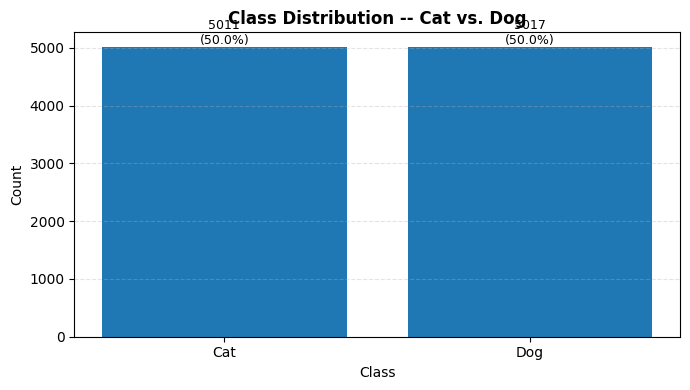

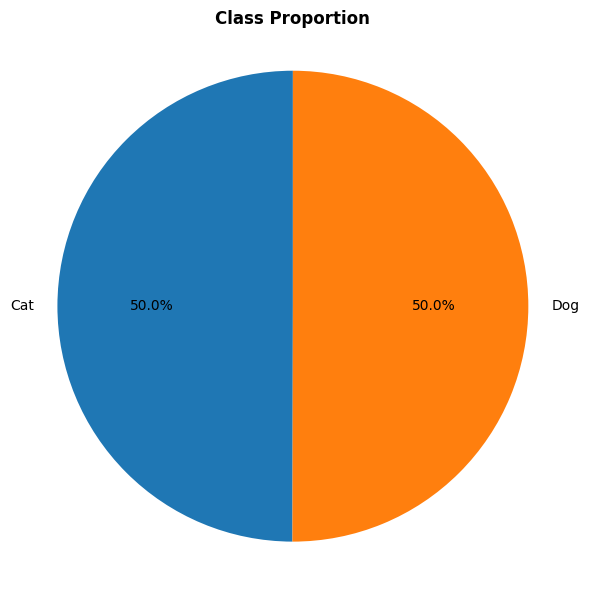

,class,count,percentage
0,Cat,5011,49.970084
1,Dog,5017,50.029916


In [13]:
from modules.visualization import plot_class_distribution_bar, plot_class_distribution_pie

plot_class_distribution_bar(
    raw_df, label_col="label_name", title="Class Distribution -- Cat vs. Dog",
    save_path=FIGURE_DIR / "01_class_bar.png"
)
plot_class_distribution_pie(
    raw_df, label_col="label_name", title="Class Proportion",
    save_path=FIGURE_DIR / "02_class_pie.png"
)

from modules.data_utils import summarize_class_distribution
display(summarize_class_distribution(raw_df))


#### 1.2.2 Image size scatter (width x height)

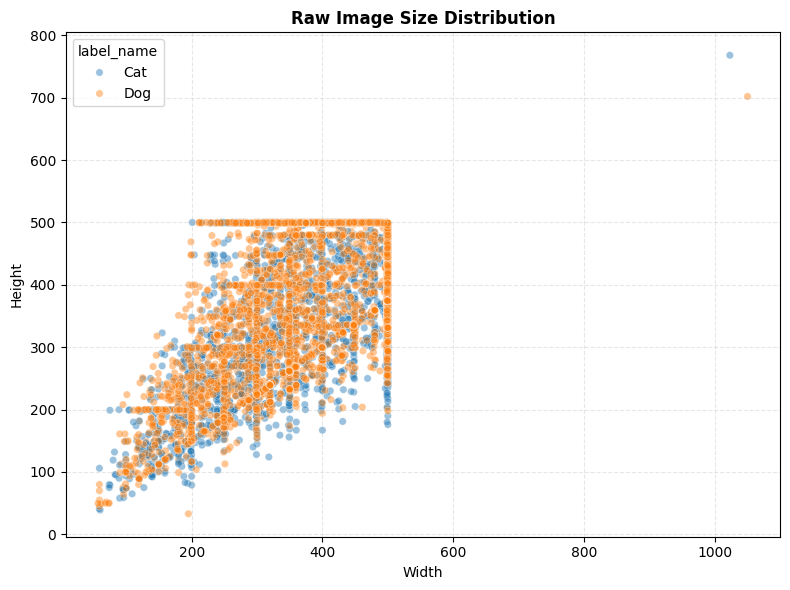

In [ ]:
from modules.visualization import plot_image_size_distribution

plot_image_size_distribution(
    audit_df, title="Raw Image Size Distribution",
    save_path=FIGURE_DIR / "03_size_scatter.png"
)


#### 1.2.3 Aspect ratio & spatial distributions

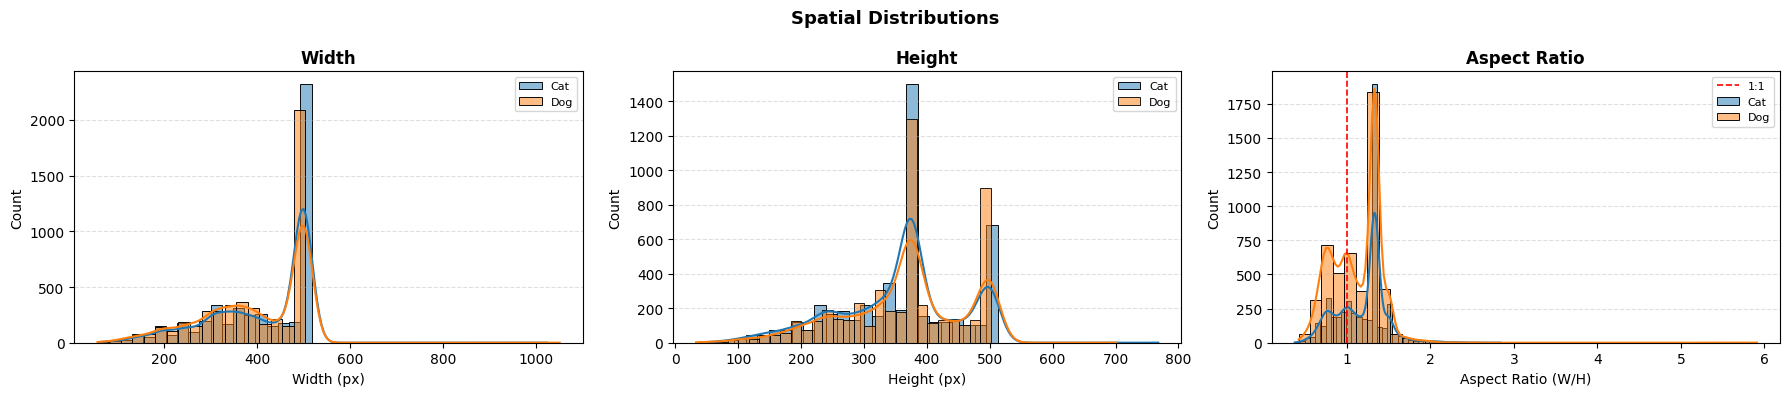

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Spatial Distributions", fontsize=13, fontweight="bold")

for ax, (col, xlabel) in zip(axes, [
    ("width", "Width (px)"), ("height", "Height (px)"), ("aspect_ratio", "Aspect Ratio (W/H)")
]):
    for lbl in audit_df["label_name"].dropna().unique():
        sns.histplot(audit_df[audit_df["label_name"]==lbl][col].dropna(),
                     bins=40, kde=True, label=lbl, alpha=0.5, ax=ax)
    if col == "aspect_ratio":
        ax.axvline(1.0, color="red", linestyle="--", lw=1.2, label="1:1")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(xlabel); ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()


#### 1.2.4 Sample image gallery

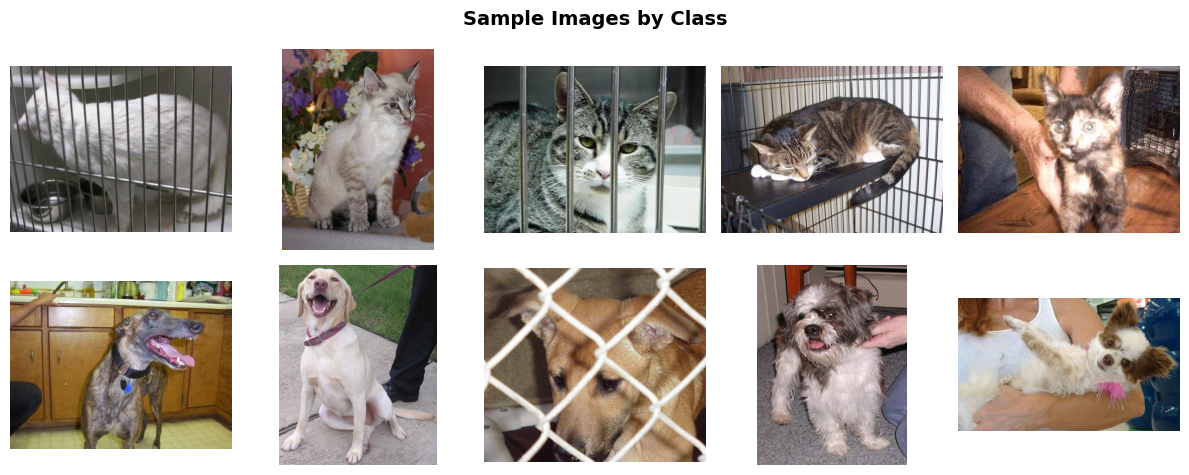

In [16]:
from modules.visualization import plot_sample_grid

plot_sample_grid(
    raw_df, n_per_class=5, path_col="path", label_col="label_name",
    seed=SEED, save_path=FIGURE_DIR / "04_sample_grid.png"
)


### 1.3 Image Quality Metrics

#### 1.3.1 Blur (Laplacian variance)

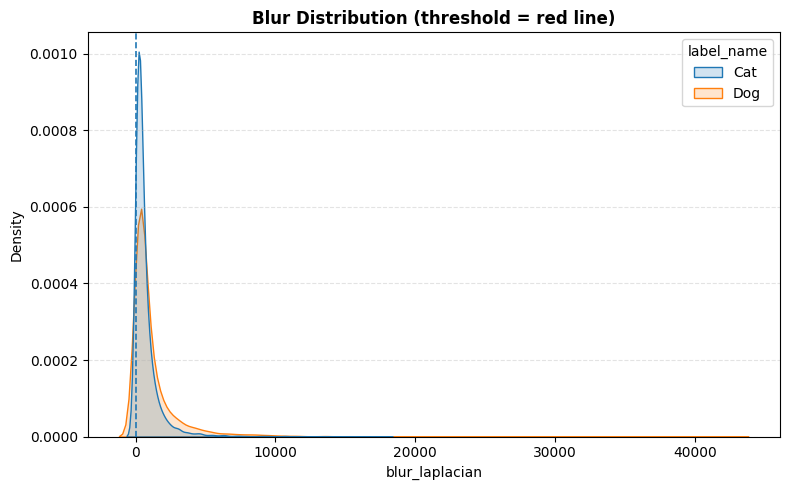

In [17]:
from modules.visualization import plot_metric_distribution

plot_metric_distribution(
    audit_df, metric="blur_laplacian", label_col="label_name",
    thresholds=[CONFIG["CLEANING"]["blur_laplacian_min"]],
    title="Blur Distribution (threshold = red line)",
    save_path=FIGURE_DIR / "05_blur_dist.png"
)


#### 1.3.2 Entropy, saturation & saliency

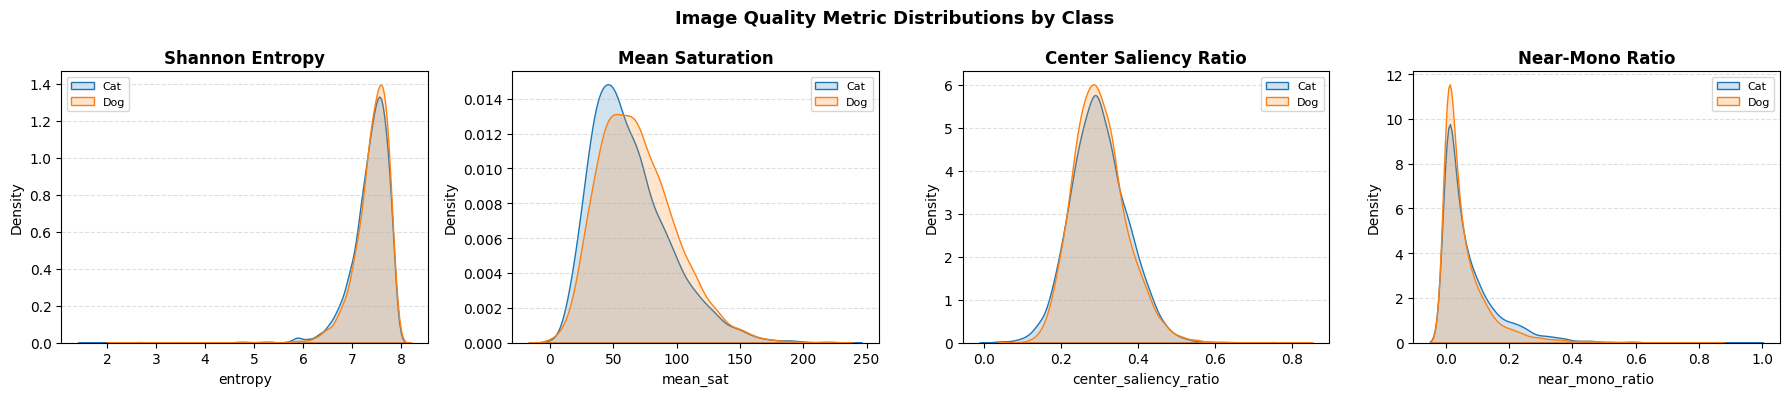

In [18]:
metrics_to_plot = [
    ("entropy",               "Shannon Entropy"),
    ("mean_sat",              "Mean Saturation"),
    ("center_saliency_ratio", "Center Saliency Ratio"),
    ("near_mono_ratio",       "Near-Mono Ratio"),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))
fig.suptitle("Image Quality Metric Distributions by Class", fontsize=13, fontweight="bold")

for ax, (metric, title) in zip(axes, metrics_to_plot):
    if metric not in audit_df.columns:
        ax.axis("off"); continue
    for lbl in audit_df["label_name"].dropna().unique():
        sub = audit_df[audit_df["label_name"]==lbl][metric].dropna()
        sns.kdeplot(sub, label=lbl, fill=True, alpha=0.2, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(metric); ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()


#### 1.3.3 Brightness distribution

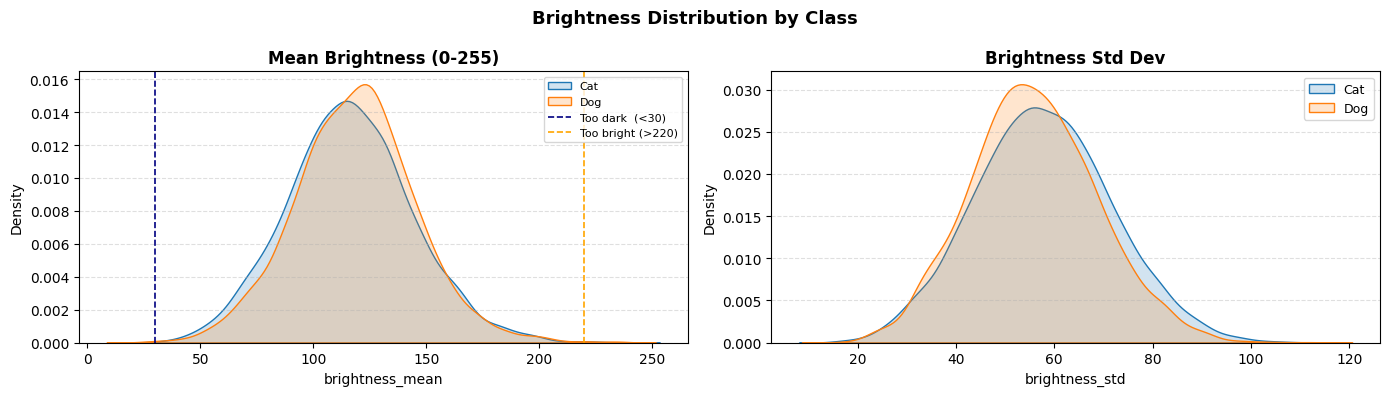

Images with mean brightness < 30  (too dark)  : 0.04%
Images with mean brightness > 220 (too bright): 0.11%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Brightness Distribution by Class", fontsize=13, fontweight="bold")

for ax, (metric, title, thresh) in zip(axes, [
    ("brightness_mean", "Mean Brightness (0-255)", None),
    ("brightness_std",  "Brightness Std Dev",      None),
]):
    for lbl in audit_df["label_name"].dropna().unique():
        sub = audit_df[audit_df["label_name"]==lbl][metric].dropna()
        sns.kdeplot(sub, label=lbl, fill=True, alpha=0.2, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(metric); ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate dark/bright extremes
axes[0].axvline(30,  color="navy",  linestyle="--", lw=1.2, label="Too dark  (<30)")
axes[0].axvline(220, color="orange",linestyle="--", lw=1.2, label="Too bright (>220)")
axes[0].legend(fontsize=8)

plt.tight_layout(); plt.show()

dark_pct   = (audit_df["brightness_mean"] < 30).mean()  * 100
bright_pct = (audit_df["brightness_mean"] > 220).mean() * 100
print(f"Images with mean brightness < 30  (too dark)  : {dark_pct:.2f}%")
print(f"Images with mean brightness > 220 (too bright): {bright_pct:.2f}%")


#### 1.3.4 Aspect ratio extremity

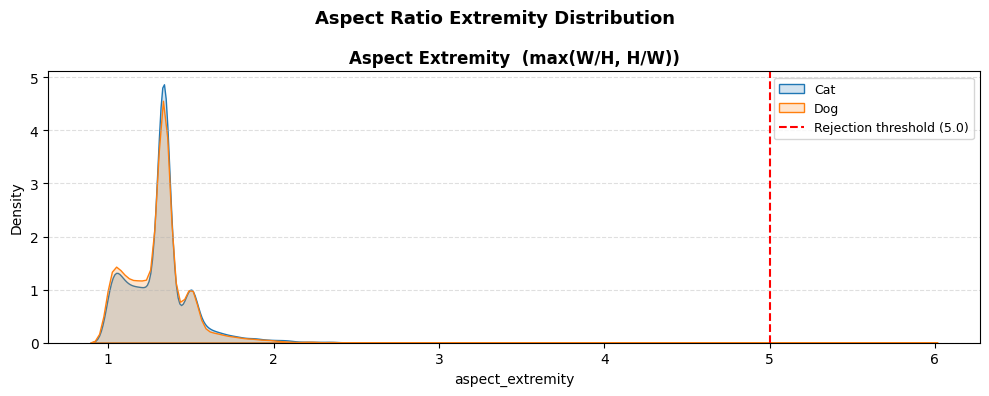

Images exceeding aspect_extremity > 5.0: 0.01%


,path,label_name,width,height,aspect_extremity
1381,/root/.cache/kagglehub/datasets/tongpython/cat...,Dog,195,33,5.909091


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Aspect Ratio Extremity Distribution", fontsize=13, fontweight="bold")

for lbl in audit_df["label_name"].dropna().unique():
    sub = audit_df[audit_df["label_name"]==lbl]["aspect_extremity"].dropna()
    sns.kdeplot(sub, label=lbl, fill=True, alpha=0.2, ax=ax)

thresh = CONFIG["CLEANING"]["aspect_extremity_max"]
ax.axvline(thresh, color="red", linestyle="--", lw=1.5,
           label=f"Rejection threshold ({thresh})")
ax.set_title("Aspect Extremity  (max(W/H, H/W))", fontweight="bold")
ax.set_xlabel("aspect_extremity"); ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()

extreme_pct = (audit_df["aspect_extremity"] > thresh).mean() * 100
print(f"Images exceeding aspect_extremity > {thresh}: {extreme_pct:.2f}%")
display(
    audit_df[audit_df["aspect_extremity"] > thresh]
    [["path","label_name","width","height","aspect_extremity"]]
    .head(5)
)


#### 1.3.5 Compression artifact distribution

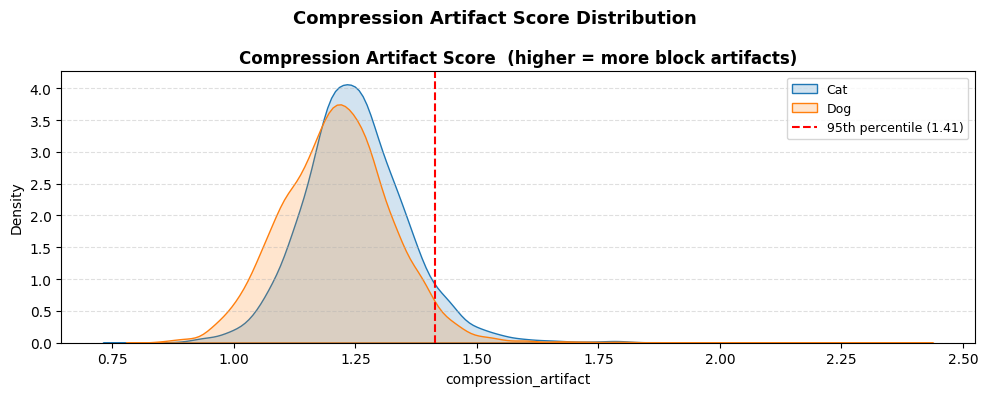

Images above 95th percentile (1.41): 5.0% of dataset

Top 5 most compressed images:


,path,label_name,compression_artifact,blur_laplacian,entropy
1684,/root/.cache/kagglehub/datasets/tongpython/cat...,Dog,2.375609,148.704652,5.906472
3190,/root/.cache/kagglehub/datasets/tongpython/cat...,Cat,2.281292,88.588648,6.506510
5946,/root/.cache/kagglehub/datasets/tongpython/cat...,Cat,2.099842,58.953084,7.384918
9271,/root/.cache/kagglehub/datasets/tongpython/cat...,Dog,1.989233,200.079068,6.971017
4156,/root/.cache/kagglehub/datasets/tongpython/cat...,Cat,1.972697,100.373178,6.956237


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Compression Artifact Score Distribution", fontsize=13, fontweight="bold")

for lbl in audit_df["label_name"].dropna().unique():
    sub = audit_df[audit_df["label_name"]==lbl]["compression_artifact"].dropna()
    sns.kdeplot(sub, label=lbl, fill=True, alpha=0.2, ax=ax)

# p95 line as a natural "high artifact" marker
p95 = audit_df["compression_artifact"].quantile(0.95)
ax.axvline(p95, color="red", linestyle="--", lw=1.5, label=f"95th percentile ({p95:.2f})")
ax.set_title("Compression Artifact Score  (higher = more block artifacts)", fontweight="bold")
ax.set_xlabel("compression_artifact"); ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()

high_artifact = (audit_df["compression_artifact"] > p95).mean() * 100
print(f"Images above 95th percentile ({p95:.2f}): {high_artifact:.1f}% of dataset")
print("\nTop 5 most compressed images:")
display(
    audit_df.nlargest(5, "compression_artifact")
    [["path","label_name","compression_artifact","blur_laplacian","entropy"]]
)


#### 1.3.6 Quality metric correlation heatmap

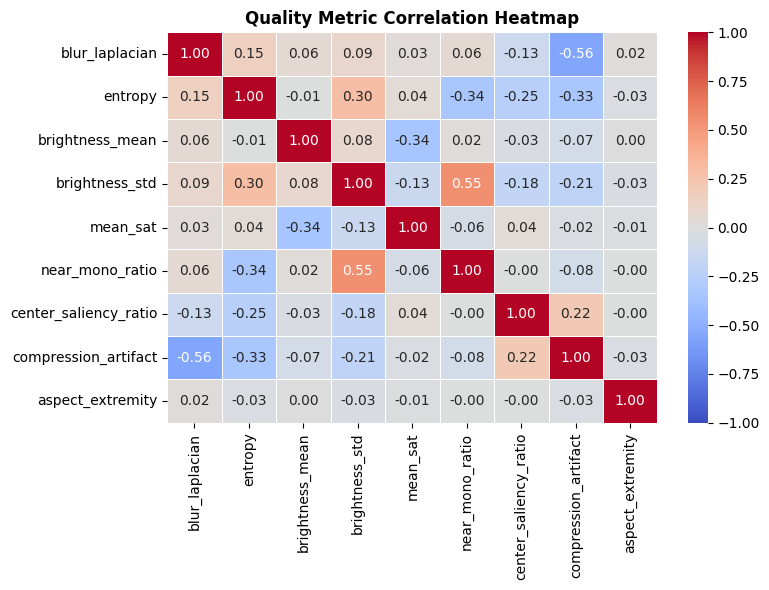

In [22]:
from modules.visualization import plot_metric_correlation_heatmap

quality_metrics = [
    "blur_laplacian", "entropy", "brightness_mean", "brightness_std",
    "mean_sat", "near_mono_ratio", "center_saliency_ratio", "compression_artifact",
    "aspect_extremity",
]
plot_metric_correlation_heatmap(
    audit_df, metrics=quality_metrics,
    title="Quality Metric Correlation Heatmap",
    save_path=FIGURE_DIR / "06_metric_corr.png"
)


### 1.4 Colour & Data Quality

#### 1.4.1 RGB channel KDE by class

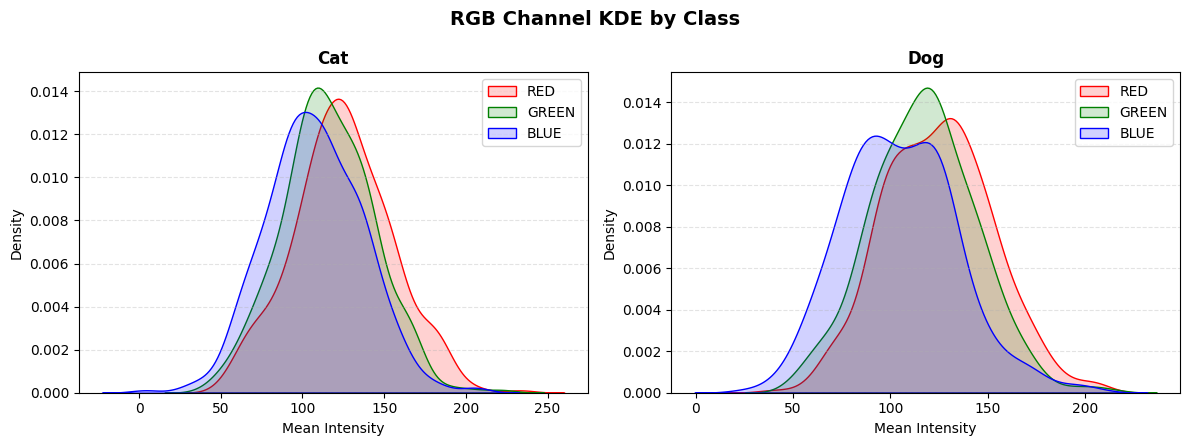

In [23]:
from modules.visualization import plot_rgb_channel_kde

plot_rgb_channel_kde(
    raw_df, sample_per_class=400, path_col="path", label_col="label_name",
    seed=SEED, save_path=FIGURE_DIR / "07_rgb_kde.png"
)


#### 1.4.2 Missing value audit

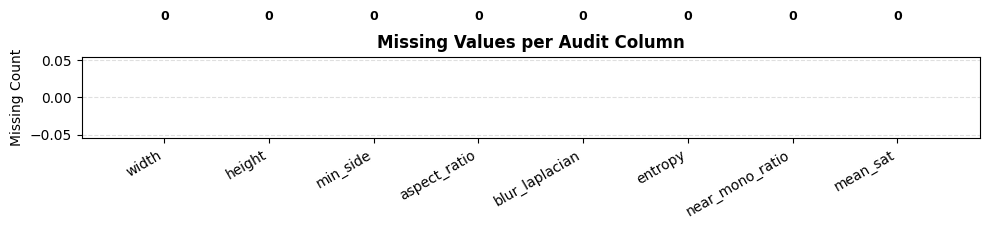

[OK] No missing values.


In [24]:
meta_cols = ["width", "height", "min_side", "aspect_ratio",
             "blur_laplacian", "entropy", "near_mono_ratio", "mean_sat"]
missing = audit_df[meta_cols].isnull().sum()

fig, ax = plt.subplots(figsize=(10, 3))
bar_colors = ["#d62728" if v > 0 else "#2ca02c" for v in missing.values]
ax.bar(missing.index, missing.values, color=bar_colors)
ax.set_title("Missing Values per Audit Column", fontweight="bold")
ax.set_ylabel("Missing Count"); ax.set_xlabel("")
for i, v in enumerate(missing.values):
    ax.text(i, v + 0.1, str(v), ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

print("[OK] No missing values." if missing.sum() == 0 else f"[WARNING] {missing.sum()} missing values.")


### 1.5 EDA Summary

| # | Finding | Evidence | Preprocessing Decision |
|---|---------|----------|------------------------|
| 1 | Balanced classes | ~50% cat / ~50% dog | No class weighting required |
| 2 | High resolution variability | Width std ~108 px, range 33-1050 px | Resize to 224x224 with letterbox |
| 3 | Slightly wider than tall | Mean aspect ratio ~1.1-1.2 | Letterbox padding preserves proportions |
| 4 | Blur is dominant quality issue | Laplacian var < 40 for ~2-3% of images | Apply blur threshold filter |
| 5 | No colour discriminability | R/G/B KDE overlaps across classes | Model relies on shape/texture features |
| 6 | Near-zero missing values | 0 nulls in all metadata columns | No imputation needed |


---
## 2. Data preparation

Utilize the modularized data utilities to perform the same data loading, cleaning and splitting process as in the classical pipeline. 

In [ ]:
from modules.data_utils import resolve_dataset_root, build_raw_dataframe, stratified_split, summarize_split_distribution
from modules.image_audit import audit_dataframe
from modules.cleaning_utils import apply_cleaning

dataset_root = resolve_dataset_root(dataset_id=CONFIG["DATASET"]["kaggle_id"])
df = build_raw_dataframe(dataset_root)

print("Auditing and cleaning dataset...")
audit_df = audit_dataframe(raw_df, compute_hash=CONFIG["CLEANING"]["remove_duplicates"])
clean_df, _ = apply_cleaning(audit_df, CONFIG["CLEANING"])

print("\nSplitting dataset...")
train_df, val_df, test_df = stratified_split(
    clean_df,
    train_ratio = CONFIG["SPLIT"]["train"],
    val_ratio   = CONFIG["SPLIT"]["val"],
    test_ratio  = CONFIG["SPLIT"]["test"],
    seed        = SEED,
)

split_summary = summarize_split_distribution(train_df, val_df, test_df)
display(split_summary)


---
## 3. Configuration & Data Loader 


Unlike the classical pipeline where features are statically extracted and saved to disk, deep learning models thrive on dynamic data loading. We use PyTorch's `DataLoader` to feed images in batches.

Crucially, we apply **Data Augmentation** (e.g., random flips, color jitter) exclusively to the training set. This artificially expands the dataset's diversity, preventing the CNN from memorizing the training data (overfitting) and improving its ability to generalize to unseen test images.

### 3.1 Define Transforms (Augmentation for Train, Standard for Val/Test)
The 'train=True' flag activates RandomHorizontalFlip and ColorJitter in our module

In [ ]:
import torch 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from modules.transforms import get_dl_transform, tensor_to_display_image
from modules.feature_extraction import  ImagePathDataset

IMAGE_SIZE = 224
BATCH_SIZE = 32 

train_transform = get_dl_transform(image_size=IMAGE_SIZE, train=True)
eval_transform = get_dl_transform(image_size=IMAGE_SIZE, train=False)

### 3.2 Create PyTorch Datasets directly from the DataFrames

In [ ]:
train_dataset = ImagePathDataset(
    paths=train_df['path'].values,
    labels=train_df['label'].values,
    transform=train_transform 
)

val_dataset = ImagePathDataset(
    paths=train_df['path'].values,
    labels=train_df['label'].values,
    transform=train_transform 
)
test_dataset = ImagePathDataset(
    paths=test_df['path'].values, 
    labels=test_df['label'].values, 
    transform=eval_transform
)

### 3.3 Initialize DataLoaders

In [ ]:
BATCH_SIZE = CONFIG["DL_TRAINING"]["batch_size"]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Number of Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

### 3.4 Sanity Check: Visualize a Training Batch with Augmentation

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i in range(4):
    img_display = tensor_to_display_image(images[i], denormalize=True)
    axes[i].imshow(img_display)
    
    class_name = "Dog" if labels[i].item() == 1 else "Cat"
    axes[i].set_title(f"Label: {class_name}")
    axes[i].axis("off")

plt.suptitle("Sanity Check: Augmented Training Batch", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. End-to-End Model Definition
Instead of extracting static features, we build an end-to-end deep learning model. We leverage Transfer Learning by initializing a pre-trained CNN (e.g., ResNet18) and replacing its final fully-connected (FC) layer to output 2 classes (Cat and Dog) instead of the original 1000 classes from ImageNet.

The entire network (or just the final layers, depending on the fine-tuning strategy) will be optimized simultaneously during training via backpropagation.

In [ ]:
import torch.nn as nn
import torchvision.models as models

def create_model(backbone_name="resnet18", num_classes=2):
    """
    Download pre-trained model and replace the Classification Head.
    """
    print(f"Initialize model: {backbone_name}...")
    
    if backbone_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif backbone_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs, num_classes)
        
    elif backbone_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    else:
        raise ValueError(f"The backbone {backbone_name} is not supported.")

    return model

BACKBONE = CONFIG["DL_TRAINING"]["backbone"]
model = create_model(backbone_name=BACKBONE, num_classes=2)

model = model.to(DEVICE)

print(f"\nModel is ready on the device: {DEVICE}")
if BACKBONE == "resnet18":
    print("Classification Head:", model.fc)
elif BACKBONE in ["vgg16", "efficientnet_b0"]:
    print("Classification Head:", model.classifier[-1])

: 

---
## 5. Loss Function & Optimizer

To train our network, we need two key components:
1. **Loss Function (Criterion):** Measures how far off the model's predictions are from the true labels. We use `CrossEntropyLoss`, which is the standard for classification tasks. It expects raw, unnormalized scores (logits) from the model.
2. **Optimizer:** The algorithm that updates the model's weights based on the calculated gradients (backpropagation). We use `Adam`, an adaptive learning rate optimization algorithm that generally converges faster than standard SGD.

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

LEARNING_RATE = CONFIG["DL_TRAINING"]["learning_rate"]

# 5.3 Initialize the Optimizer
# We use filter() to only pass parameters that require gradients. 
# This is a best practice in Transfer Learning, ensuring that if you freeze 
# the backbone layers later, the optimizer won't try to update them.
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

print("Training setup complete:")
print(f"- Loss Function : {criterion.__class__.__name__}")
print(f"- Optimizer     : {optimizer.__class__.__name__} (LR: {LEARNING_RATE})")

---
## 6. Training & Validation Loop (End-to-End Learning)

This section contains the core of the Deep Learning pipeline. We loop over the dataset for a specified number of epochs. Each epoch consists of two phases:
1. **Training Phase:** We perform the forward pass, compute the loss, execute backpropagation (`loss.backward()`), and update the model weights (`optimizer.step()`).
2. **Validation Phase:** We evaluate the model on the unseen validation set. We use `torch.no_grad()` to disable gradient computation, which saves memory and speeds up execution.

We will track the loss and accuracy for both phases to visualize the learning progress later.

In [ ]:
import time

# 6.1 Retrieve the number of epochs from configuration
NUM_EPOCHS = CONFIG["DL_TRAINING"]["epochs"]

# Dictionary to store metrics for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print(f"Starting training for {NUM_EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # ==========================================
    #               TRAINING PHASE
    # ==========================================
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # 1. Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()
        
        # 2. Forward pass: Compute predictions
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 3. Backward pass: Compute gradients
        loss.backward()
        
        # 4. Optimizer step: Update weights
        optimizer.step()
        
        # Record statistics
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Calculate average loss and accuracy for the training epoch
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train
    
    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval() # Set model to evaluation mode (disables Dropout, freezes BatchNorm)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Disable gradient calculation for memory efficiency and speed
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            # Forward pass only
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Record statistics
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Calculate average loss and accuracy for the validation epoch
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val
    
    # ==========================================
    #              LOGGING & METRICS
    # ==========================================
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    elapsed_time = time.time() - start_time
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Time: {elapsed_time:.0f}s")
    print(f"  Train -> Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f}")
    print(f"  Val   -> Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}\n")

# Save the trained model weights
model_save_path = MODEL_DIR / f"{BACKBONE_NAME}_finetuned.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Training complete. Model weights saved to: {model_save_path}")

## 7. Model Evaluation & Visualization

After training the model end-to-end, it is crucial to evaluate its performance. 
First, we plot the **Learning Curves** (Loss and Accuracy over epochs) to check for signs of overfitting or underfitting. 
Second, we evaluate the fine-tuned model on the **Test Set**—data it has never seen during training or validation—to get its final, objective performance metrics. We will visualize this using a Classification Report and a Confusion Matrix.

### 7.1 Plot Training vs. Validation Learning Curves

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss Plot
ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue')
ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='o', color='orange')
ax1.set_title('Cross Entropy Loss over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Accuracy Plot
ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='green')
ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o', color='red')
ax2.set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Save and show
learning_curve_path = FIGURE_DIR / "dl_learning_curves.png"
plt.savefig(learning_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Learning curves saved to: {learning_curve_path}")

### 7.2 Evaluate on the Unseen Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.eval() # Ensure model is in evaluation mode
all_preds = []
all_labels = []

print("Evaluating model on the Test Set...\n")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        outputs = model(inputs)
        
        # Get predictions
        _, preds = torch.max(outputs, 1)
        
        # Store predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 7.3 Print Classification Report
class_names = ['Cat', 'Dog'] # 0: Cat, 1: Dog
print("--------------------------------------------------")
print("             TEST SET CLASSIFICATION REPORT       ")
print("--------------------------------------------------")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 7.4 Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Deep Learning Pipeline - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Save and show
cm_path = FIGURE_DIR / "dl_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrix saved to: {cm_path}")